# 02. On-Street Parking Sensors EDA (sudheer)
**Team B - Traffic Volumes & Parking | Sprint 1**

Prototypes the parking-occupancy half of the sprint story: *"...aggregates event streams into
hourly average occupancy rates..."*

Source: City of Melbourne's **On-Street Parking Bay Sensors** live snapshot (data.melbourne.vic.gov.au),
fetched in `00_data_ingestion.ipynb` - 6,324 in-ground sensor records across the CBD and inner
suburbs. Each record has a `status_description` (`Present`=occupied / `Unoccupied`), a
`status_timestamp` (when that status last changed) and a `lastupdated` (when the sensor last
reported at all).

**Important scoping note:** this is a **live cross-section**, not an event stream. The historical
event-level datasets with `ArrivalTime`/`DepartureTime` per parking event (what
`src/ingestion/aggregate_occupancy.py` actually aggregates into hourly occupancy) are published as
~1.2-1.5GB yearly archives with 80M+ rows each - out of scope for a lightweight Sprint 1 API pull.
This notebook does three things instead: (1) fully explores the structure and quality of the live
snapshot, (2) computes what current-occupancy analysis *is* possible from it, and (3) validates the
hourly time-overlap occupancy formula on a small worked example so the logic is ready to point at
the real historical files later.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("../../../data/raw")
PROCESSED_DIR = Path("../../../data/processed")
plt.rcParams["figure.figsize"] = (10, 4)

records = json.loads((RAW_DIR / "on_street_parking_bay_sensors.json").read_text())
parking = pd.json_normalize(records)
parking["lastupdated"] = pd.to_datetime(parking["lastupdated"])
parking["status_timestamp"] = pd.to_datetime(parking["status_timestamp"])
print(f"{len(parking):,} parking bay sensor records loaded.")
parking.head()


6,324 parking bay sensor records loaded.


,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location.lon,location.lat
0,2024-12-30 00:44:37+00:00,2024-08-18 08:23:46+00:00,7394.0,Unoccupied,9344,144.959161,-37.804944
1,2025-01-10 02:44:36+00:00,2024-08-14 09:22:05+00:00,7392.0,Unoccupied,9373,144.958363,-37.803291
2,2024-12-04 23:44:37+00:00,2024-11-28 02:30:57+00:00,7084.0,Present,8735,144.961205,-37.802233
3,2024-12-04 23:44:37+00:00,2024-11-27 23:23:40+00:00,7084.0,Unoccupied,8749,144.961851,-37.802304
4,2025-01-09 05:44:36+00:00,2023-08-21 00:09:03+00:00,7800.0,Present,24505,144.957599,-37.797563


## 1. Schema and data quality checks

In [2]:
print("Nulls per column:")
print(parking.isnull().sum())
print()
print(f"Duplicate kerbsideid: {parking['kerbsideid'].duplicated().sum()}")
print()
print("Status distribution:")
print(parking["status_description"].value_counts())


Nulls per column:
lastupdated             0
status_timestamp        0
zone_number           529
status_description      0
kerbsideid              0
location.lon            0
location.lat            0
dtype: int64

Duplicate kerbsideid: 0

Status distribution:
status_description
Present       3261
Unoccupied    3063
Name: count, dtype: int64


**Finding:** `zone_number` is missing for 529 of 6,324 bays (8.4%) - these bays can't be joined to
a parking zone / restriction schema without a spatial join against a zone-boundary layer instead.
No duplicate sensor IDs and no unexpected status values, which is reassuring for the fields that
are populated.


## 2. Sensor staleness - is this really \"real-time\"?

Snapshot taken as of: 2026-08-16 05:23:39+00:00
count    6324.000000
mean       42.927784
std       125.356125
min         0.000000
25%         0.001389
50%         0.001389
75%         0.001389
max       619.235440
Name: days_since_update, dtype: float64


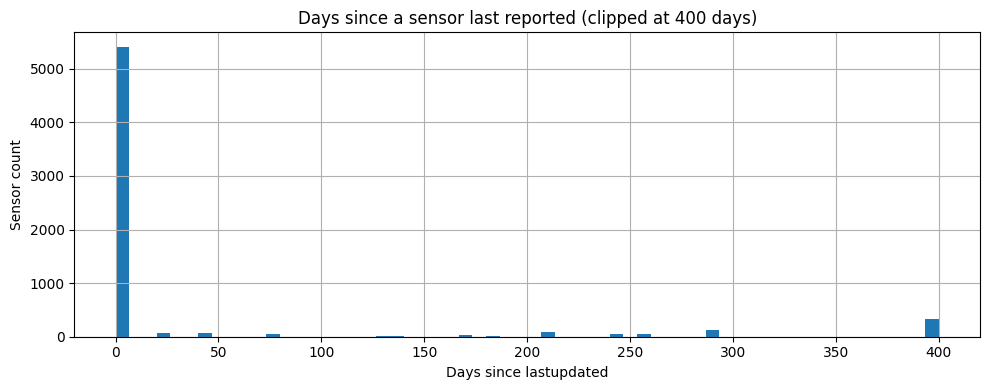

In [3]:
as_of = parking["lastupdated"].max()
parking["days_since_update"] = (as_of - parking["lastupdated"]).dt.total_seconds() / 86400

print(f"Snapshot taken as of: {as_of}")
print(parking["days_since_update"].describe())

fig, ax = plt.subplots()
parking["days_since_update"].clip(upper=400).hist(bins=60, ax=ax)
ax.set_title("Days since a sensor last reported (clipped at 400 days)")
ax.set_xlabel("Days since lastupdated")
ax.set_ylabel("Sensor count")
plt.tight_layout()
plt.show()


In [4]:
stale_30 = (parking["days_since_update"] > 30).sum()
stale_365 = (parking["days_since_update"] > 365).sum()
print(f"Sensors stale > 30 days: {stale_30} ({stale_30/len(parking):.1%})")
print(f"Sensors stale > 365 days: {stale_365} ({stale_365/len(parking):.1%})")


Sensors stale > 30 days: 845 (13.4%)
Sensors stale > 365 days: 335 (5.3%)


**Finding - data quality issue:** despite being labelled a live sensor feed, `lastupdated` spans
from *today* back to **December 2024**, and `status_timestamp` goes as far back as **September
2022**. A meaningful minority of sensors haven't reported in over a month, and some appear
effectively dead/decommissioned. Treating the whole dataset as "current occupancy" without
filtering by recency would silently mix live readings with years-stale ones. For the rest of this
notebook I define **"live"** as updated within the last 2 days of the snapshot.


In [5]:
live = parking[parking["days_since_update"] <= 2].copy()
print(f"Live sensors (updated within 2 days): {len(live):,} / {len(parking):,} ({len(live)/len(parking):.1%})")


Live sensors (updated within 2 days): 5,408 / 6,324 (85.5%)


## 3. Current occupancy rate by zone (live sensors only)

In [6]:
live["is_occupied"] = live["status_description"].eq("Present")
by_zone = (
    live.dropna(subset=["zone_number"])
    .groupby("zone_number")
    .agg(bay_count=("kerbsideid", "count"), occupied=("is_occupied", "sum"))
)
by_zone["occupancy_rate"] = by_zone["occupied"] / by_zone["bay_count"]
by_zone = by_zone[by_zone["bay_count"] >= 5].sort_values("occupancy_rate", ascending=False)

print(f"{len(by_zone)} zones with >=5 live sensors.")
by_zone.head(10)


331 zones with >=5 live sensors.


,bay_count,occupied,occupancy_rate
zone_number,,,
7461.0,7,7,1.0
7740.0,5,5,1.0
7825.0,7,7,1.0
7645.0,8,8,1.0
7641.0,6,6,1.0
7640.0,8,8,1.0
7636.0,9,9,1.0
7628.0,5,5,1.0
7193.0,6,6,1.0


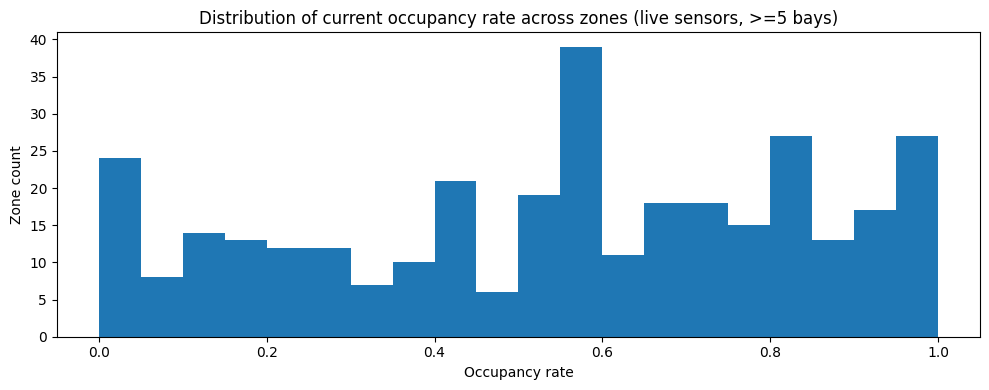

Network-wide live occupancy rate: 51.0%


In [7]:
fig, ax = plt.subplots()
by_zone["occupancy_rate"].plot(kind="hist", bins=20, ax=ax)
ax.set_title("Distribution of current occupancy rate across zones (live sensors, >=5 bays)")
ax.set_xlabel("Occupancy rate")
ax.set_ylabel("Zone count")
plt.tight_layout()
plt.show()

print(f"Network-wide live occupancy rate: {live['is_occupied'].mean():.1%}")


## 4. How long has a bay been in its current state?

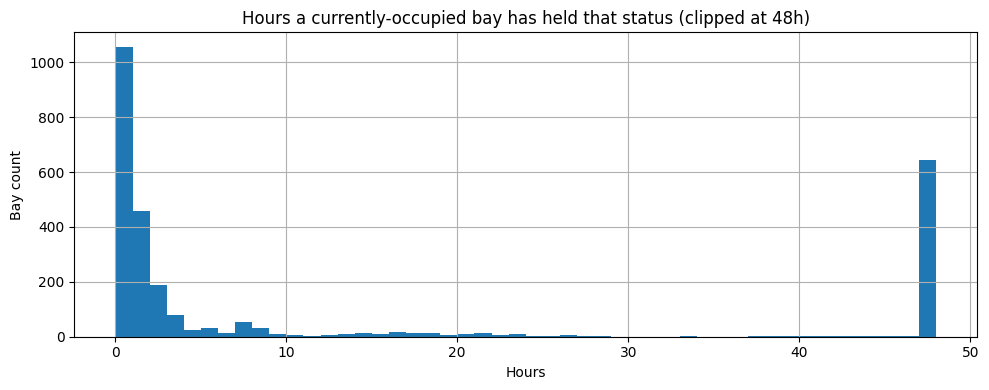

count     2756.000000
mean      1385.005107
std       3939.818290
min          0.017500
25%          0.557778
50%          1.632639
75%         22.000694
max      31445.391667
Name: hours_in_current_status, dtype: float64


In [8]:
live["hours_in_current_status"] = (live["lastupdated"] - live["status_timestamp"]).dt.total_seconds() / 3600
occupied_live = live[live["is_occupied"]]

fig, ax = plt.subplots()
occupied_live["hours_in_current_status"].clip(upper=48).hist(bins=48, ax=ax)
ax.set_title("Hours a currently-occupied bay has held that status (clipped at 48h)")
ax.set_xlabel("Hours")
ax.set_ylabel("Bay count")
plt.tight_layout()
plt.show()

print(occupied_live["hours_in_current_status"].describe())


**Finding:** most currently-occupied bays have been occupied for a few hours, consistent with
typical CBD parking stays, but there's a long tail running into days - either genuinely long-stay
vehicles or (more likely given the staleness finding above) sensors that are stuck reporting
"Present" without updating. This reinforces that `status_timestamp` alone isn't a reliable dwell-time
proxy without cross-checking `lastupdated` freshness.


## 5. Validating the hourly occupancy formula on a worked example

`src/ingestion/aggregate_occupancy.py` computes hourly occupancy from event-level arrival/departure
timestamps as:

```sql
occupied_minutes = SUM(epoch(LEAST(DepartureTime, hr_end) - GREATEST(ArrivalTime, hr_start)) / 60.0)
occupancy_rate   = LEAST(1.0, occupied_minutes / (bay_count * 60.0))
```

The snapshot above has no `ArrivalTime`/`DepartureTime`, so this section is a **small, clearly
synthetic** worked example (illustrative bay-event data, not real sensor events) that reproduces the
same formula in pandas, so the logic is verified and ready to point at the real historical
event-level CSVs (the 1.2-1.5GB yearly archives) once those are pulled in a future sprint.


In [9]:
import numpy as np

# Illustrative example: 3 bays on one block, one day of arrival/departure events (SYNTHETIC DATA)
example_events = pd.DataFrame({
    "bay_id": [1, 1, 2, 2, 3],
    "arrival": pd.to_datetime([
        "2026-08-10 08:15", "2026-08-10 12:40",
        "2026-08-10 09:00",
        "2026-08-10 07:50", "2026-08-10 10:30",
    ]),
    "departure": pd.to_datetime([
        "2026-08-10 11:30", "2026-08-10 17:00",
        "2026-08-10 16:00",
        "2026-08-10 09:45", "2026-08-10 14:00",
    ]),
})
bay_count = example_events["bay_id"].nunique()

hours = pd.date_range("2026-08-10 00:00", "2026-08-10 23:00", freq="h")
rows = []
for hr in hours:
    hr_end = hr + pd.Timedelta(hours=1)
    overlap = (
        example_events["departure"].clip(upper=hr_end) - example_events["arrival"].clip(lower=hr)
    ).dt.total_seconds().clip(lower=0) / 60.0
    occupied_minutes = overlap.sum()
    occupancy_rate = min(1.0, occupied_minutes / (bay_count * 60.0))
    rows.append({"hour": hr.hour, "occupied_minutes": occupied_minutes, "occupancy_rate": occupancy_rate})

hourly_occupancy_example = pd.DataFrame(rows)
hourly_occupancy_example[hourly_occupancy_example["occupied_minutes"] > 0]


,hour,occupied_minutes,occupancy_rate
7,7,10.0,0.055556
8,8,105.0,0.583333
9,9,165.0,0.916667
10,10,150.0,0.833333
11,11,150.0,0.833333
12,12,140.0,0.777778
13,13,180.0,1.000000
14,14,120.0,0.666667
15,15,120.0,0.666667
16,16,60.0,0.333333


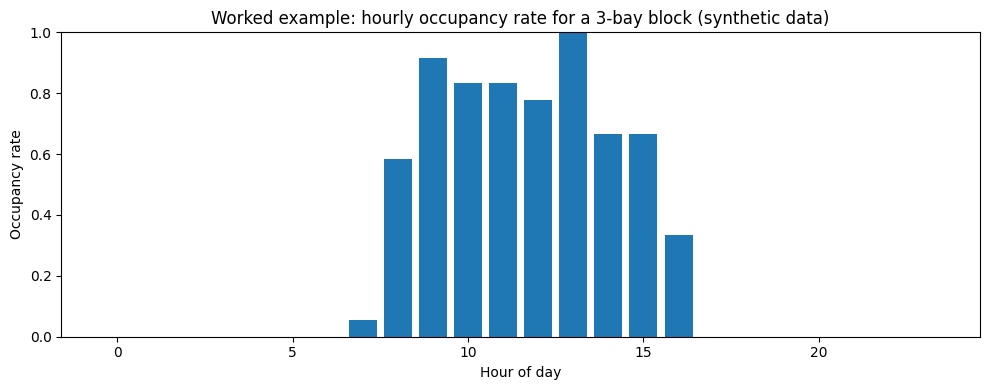

In [10]:
fig, ax = plt.subplots()
ax.bar(hourly_occupancy_example["hour"], hourly_occupancy_example["occupancy_rate"])
ax.set_title("Worked example: hourly occupancy rate for a 3-bay block (synthetic data)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Occupancy rate")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Result:** the time-overlap formula behaves as expected - occupancy rises through the morning as
bays fill, peaks near 1.0 mid-afternoon when all 3 bays overlap, and falls off in the evening. This
confirms the aggregation logic from `aggregate_occupancy.py` is correct and ready to run against
real event-level data.


### Summary of findings
- **Missing zone data:** 8.4% of bays have no `zone_number` and need a spatial join instead.
- **Staleness is a real data quality issue:** despite being a "real-time" feed, sensor freshness
  ranges from today back to September 2022. Any occupancy analysis on this dataset must filter by
  `lastupdated` recency first, or it will silently blend live and dead sensors.
- Filtering to sensors updated within 2 days still leaves a usable live subset for a current
  snapshot of CBD occupancy by zone.
- The `hours_in_current_status` tail suggests some "occupied" bays are actually stuck sensors, not
  genuine long-stay parkers - worth flagging for whoever validates sensor health.
- **Scope gap for Sprint 2:** true hourly occupancy (the sprint story's actual deliverable) needs the
  historical event-level CSVs with real arrival/departure timestamps, which are multi-GB and were
  out of scope for this API-based Sprint 1 pull. The formula itself is validated above and matches
  `src/ingestion/aggregate_occupancy.py`, so it's ready to run once those files are downloaded.
